# 03 — Structured Participation Note (Phase 4)

A capital-protected **participation note** on the KC=F frozen curve: principal repaid at maturity plus a participation rate times the underlying's upside. Priced **two ways** — Black-76 closed form and Monte Carlo — so the MC engine is validated, not just runnable (spec story 9). Then the issuer's delta/vega hedge profile, and the product-governance page.

Conventions follow the package: prices in cents/lb, vol decimal, T years, SOFR discounting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hedging_workbench.carry import load_curve
from hedging_workbench.data.rates import latest_rate
from hedging_workbench.vol import vol_from_frozen
from hedging_workbench.note import ParticipationNote, render_governance

curve = load_curve("coffee")
rets, vol_fit = vol_from_frozen()
r = latest_rate()
sigma = vol_fit.garch_last / 100.0   # consistent with notebook 02

# canonical note: $1M on the 1-year point of the frozen curve (Sep 2027)
leg = curve[np.isclose(curve["ttm"], 1.029432, atol=0.01)].iloc[0]
f0, T = float(leg["price"]), float(leg["ttm"])
note = ParticipationNote(notional=1_000_000, f0=f0, tenor=T,
                         participation=0.6)
print(f"underlying {leg['label']}  F0={f0:.2f} c/lb  T={T:.4f} yr")
print(f"r={r:.4f}  sigma(GARCH last)={sigma:.4f}  (long-run {vol_fit.garch_longrun/100:.4f})")

underlying Sep 2027  F0=281.45 c/lb  T=1.0294 yr
r=0.0366  sigma(GARCH last)=0.3924  (long-run 0.3854)


## 1. Closed-form price

Per unit notional: discounted zero-coupon principal plus the participation rate times an ATM Black-76 call on the forward, expressed as a fraction of F0.

In [2]:
cf = note.closed_form(sigma, r)
pd.Series({k: round(v, 6) for k, v in cf.items()})

bond                   0.963024
call                   0.151964
participation_value    0.091178
price                  1.054202
dtype: float64

The bond leg is the SOFR-discounted principal; the 60% participation in a 1-year ATM call adds the rest. The participation rate is the issuer's margin lever: each point granted costs Black-76/100 per unit notional.

## 2. Monte Carlo + convergence

Risk-neutral lognormal martingale paths (E[F_T] = F0), antithetic variates, pathwise payoff discounting. **The trust check:** the MC price's 95% CI must contain the closed form, with the standard error shrinking ~1/√n.

In [3]:
rows = []
for n in (20_000, 80_000, 320_000, 1_280_000):
    mc = note.mc_price(sigma, r, n_paths=n, seed=42)
    rows.append({"n_paths": n, "mc_price": round(mc["price"], 6),
                 "se": round(mc["se"], 6),
                 "ci_lo": round(mc["ci95"][0], 6),
                 "ci_hi": round(mc["ci95"][1], 6),
                 "closed_form_in_ci": mc["ci95"][0] < cf["price"] < mc["ci95"][1]})
conv = pd.DataFrame(rows)
conv

,n_paths,mc_price,se,ci_lo,ci_hi,closed_form_in_ci
0,20000,1.054808,0.001231,1.052395,1.057221,True
1,80000,1.054736,0.000609,1.053541,1.055930,True
2,320000,1.054639,0.000305,1.054041,1.055236,True
3,1280000,1.054289,0.000152,1.053992,1.054586,True


Standard error falls by ~2× per 4× paths (central-limit behavior), and the closed form sits inside every CI — two engines, one number. The MC engine is calibrated, not merely implemented.

## 3. Issuer hedge: delta / vega

The issuer is **short** the call leg (long the bond), so its delta and vega are negative. Analytic Black-76 greeks are cross-validated by bump-and-reprice in the MC engine.

In [4]:
g = note.greeks(sigma, r)
mg = note.mc_greeks(sigma, r, n_paths=400_000, seed=11)
greeks = pd.DataFrame({
    "analytic": g, "mc_bump": mg,
    "agree": {k: bool(np.isclose(g[k], mg[k], rtol=0.15)) for k in g}})
greeks

,analytic,mc_bump,agree
delta,-0.000865,-0.000863,True
vega,-0.229293,-0.229036,True


Analytic and MC greeks agree — the issuer is short delta per unit notional (a few hundred dollars per ¢/lb move on the $1M note) and short vega.

In [5]:
# hedge profile: delta/vega across spot x participation grid
spot_grid = np.linspace(0.8 * f0, 1.2 * f0, 9)
parts = (0.25, 0.5, 0.75, 1.0)
prof = pd.DataFrame(
    {f"p={p:.0%}": [ParticipationNote(1e6, s, T, p).greeks(sigma, r)["delta"]
                    for s in spot_grid] for p in parts},
    index=[f"{s:.0f}" for s in spot_grid])
prof.round(6)

,p=25%,p=50%,p=75%,p=100%
225,-0.000450,-0.000901,-0.001351,-0.001801
239,-0.000424,-0.000848,-0.001271,-0.001695
253,-0.000400,-0.000800,-0.001201,-0.001601
267,-0.000379,-0.000758,-0.001138,-0.001517
281,-0.000360,-0.000720,-0.001081,-0.001441
296,-0.000343,-0.000686,-0.001029,-0.001372
310,-0.000327,-0.000655,-0.000982,-0.001310
324,-0.000313,-0.000626,-0.000940,-0.001253
338,-0.000300,-0.000600,-0.000901,-0.001201


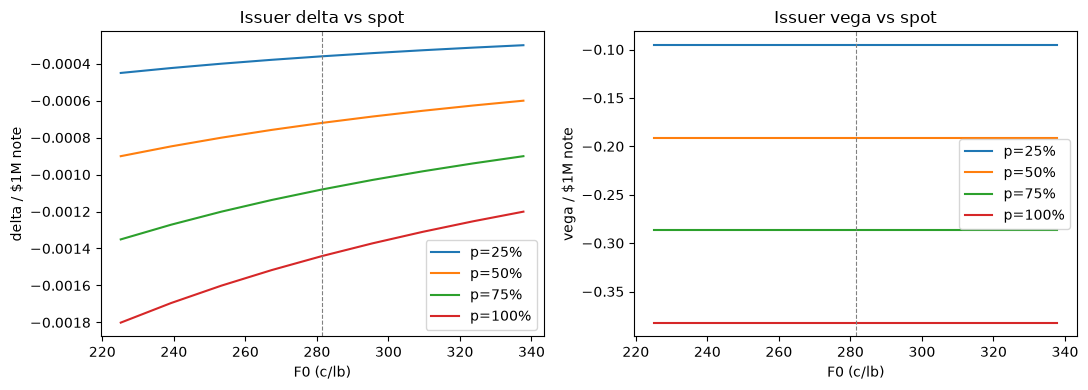

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for p in parts:
    deltas = [ParticipationNote(1e6, s, T, p).greeks(sigma, r)["delta"] for s in spot_grid]
    vegas  = [ParticipationNote(1e6, s, T, p).greeks(sigma, r)["vega"] for s in spot_grid]
    axes[0].plot(spot_grid, deltas, label=f"p={p:.0%}")
    axes[1].plot(spot_grid, vegas, label=f"p={p:.0%}")
axes[0].set(title="Issuer delta vs spot", xlabel="F0 (c/lb)", ylabel="delta / $1M note")
axes[1].set(title="Issuer vega vs spot", xlabel="F0 (c/lb)", ylabel="vega / $1M note")
for ax in axes: ax.axvline(f0, ls="--", lw=0.8, c="grey"); ax.legend()
plt.tight_layout()

Delta and vega both grow in magnitude as the note goes further in the money and as participation rises — the issuer's short optionality is worst exactly when the client is winning. A delta hedge would be a short futures position rolled with the note's spot path; the vega cannot be hedged without other coffee options (none free-quoted), which is why the participation rate itself is the pricing lever.

## 4. Product governance & disclosure

Rendered from the note's own parameters via the package API (MiFID II product-governance / PRIIPs KID *template* — mapped, not a compliance artifact).

In [7]:
print(render_governance(note, sigma, r))

# Participation Note — Product Governance & Disclosure Page

**Underlying:** ICE Coffee C futures (KC=F) (reference price 281.45 ¢/lb)
**Notional:** $1,000,000 · **Tenor:** 1.03 yr · **Participation rate:** 60% · **Strike:** 281.45 ¢/lb (ATM)
**Structure:** 100% principal protection + 60% of the underlying's upside (call payoff / reference price). Per unit notional: bond leg 0.9630, option leg 0.0912 at the pricing vol.

## Target market (MiFID II product governance template)

- Investors seeking commodity exposure with defined downside (principal protected at maturity) and accepting capped-in-structure participation.
- NOT for investors needing liquidity before maturity, income, or unlimited participation.

## Risk factors (not hedged by the structure)

- **Issuer credit risk:** principal protection is only as good as the issuer — a CVA/PFE exercise (Phase 5) quantifies this.
- **Liquidity:** no secondary market; value before maturity is a model mark, not a tradeable price.
- **Gap ri

## Takeaways

- **Two-way pricing discipline:** closed form and MC agree inside CI on real frozen data — the MC engine is trusted before it is used for anything that has no closed form (Phase 5 exposure simulation).
- **Issuer position:** short a call on coffee; delta/vega both negative and state-dependent — hedging cost is the reason participation < 100%.
- **Governance as code:** the disclosure page regenerates from the note's parameters, so the artifact can never drift from the product.